In [1]:
import torch
from urllib.request import urlopen
from PIL import Image
from open_clip import create_model_from_pretrained, get_tokenizer

# Load the model and config files from the Hugging Face Hub
model, preprocess = create_model_from_pretrained('hf-hub:microsoft/BiomedCLIP-PubMedBERT_256-vit_base_patch16_224')
tokenizer = get_tokenizer('hf-hub:microsoft/BiomedCLIP-PubMedBERT_256-vit_base_patch16_224')


# Zero-shot image classification
template = 'this is a photo of '
labels = [
    'adenocarcinoma histopathology',
    'brain MRI',
    'covid line chart',
    'squamous cell carcinoma histopathology',
    'immunohistochemistry histopathology',
    'bone X-ray',
    'chest X-ray',
    'pie chart',
    'hematoxylin and eosin histopathology'
]

dataset_url = 'https://huggingface.co/microsoft/BiomedCLIP-PubMedBERT_256-vit_base_patch16_224/resolve/main/example_data/biomed_image_classification_example_data/'
test_imgs = [
    'squamous_cell_carcinoma_histopathology.jpeg',
    'H_and_E_histopathology.jpg',
    'bone_X-ray.jpg',
    'adenocarcinoma_histopathology.jpg',
    'covid_line_chart.png',
    'IHC_histopathology.jpg',
    'chest_X-ray.jpg',
    'brain_MRI.jpg',
    'pie_chart.png'
]
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
model.to(device)
model.eval()

context_length = 256

images = torch.stack([preprocess(Image.open(urlopen(dataset_url + img))) for img in test_imgs]).to(device)
texts = tokenizer([template + l for l in labels], context_length=context_length).to(device)
with torch.no_grad():
    image_features, text_features, logit_scale = model(images, texts)

    logits = (logit_scale * image_features @ text_features.t()).detach().softmax(dim=-1)
    sorted_indices = torch.argsort(logits, dim=-1, descending=True)

    logits = logits.cpu().numpy()
    sorted_indices = sorted_indices.cpu().numpy()

top_k = -1

for i, img in enumerate(test_imgs):
    pred = labels[sorted_indices[i][0]]

    top_k = len(labels) if top_k == -1 else top_k
    print(img.split('/')[-1] + ':')
    for j in range(top_k):
        jth_index = sorted_indices[i][j]
        print(f'{labels[jth_index]}: {logits[i][jth_index]}')
    print('\n')


/home/tpadhi1/miniconda3/envs/llava/lib/python3.10/site-packages/transformers/utils/generic.py:482: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.
  _torch_pytree._register_pytree_node(
/home/tpadhi1/miniconda3/envs/llava/lib/python3.10/site-packages/transformers/utils/hub.py:128: FutureWarning: Using `TRANSFORMERS_CACHE` is deprecated and will be removed in v5 of Transformers. Use `HF_HOME` instead.
  warnings.warn(
/home/tpadhi1/miniconda3/envs/llava/lib/python3.10/site-packages/transformers/utils/generic.py:339: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.
  _torch_pytree._register_pytree_node(
/home/tpadhi1/miniconda3/envs/llava/lib/python3.10/site-packages/transformers/utils/generic.py:339: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.registe

squamous_cell_carcinoma_histopathology.jpeg:
squamous cell carcinoma histopathology: 0.9966331124305725
adenocarcinoma histopathology: 0.0017274463316425681
hematoxylin and eosin histopathology: 0.0015929165529087186
immunohistochemistry histopathology: 4.655355223803781e-05
chest X-ray: 1.3614282444451842e-11
brain MRI: 5.811991079379686e-12
pie chart: 2.8403501339119286e-12
covid line chart: 9.729035068892222e-13
bone X-ray: 2.909474148150154e-14


H_and_E_histopathology.jpg:
hematoxylin and eosin histopathology: 0.9874189496040344
immunohistochemistry histopathology: 0.012369180098176003
adenocarcinoma histopathology: 0.0001461862411815673
squamous cell carcinoma histopathology: 5.225370841799304e-05
brain MRI: 1.0751925401564222e-05
chest X-ray: 1.7534067637825501e-06
bone X-ray: 6.792607223360392e-07
pie chart: 2.49991899181623e-07
covid line chart: 4.002828971061412e-11


bone_X-ray.jpg:
bone X-ray: 0.9994805455207825
pie chart: 0.00044735203846357763
brain MRI: 4.304997128201648

In [4]:
## ok cool, now lets see for some responses, 
## load the responses
import os  

path = '/staging/users/tpadhi1/Multimodal-Uncertainty-Quantification/runs_slake/llava_med_slake'
explanations_path = os.path.join(path, 'explanations')
explantion_files = os.listdir(explanations_path)

# read the first file 
explantion_file_0 = explantion_files[0]
explantion_file_0_path = os.path.join(explanations_path, explantion_file_0)

# its a pickle file
import pickle
with open(explantion_file_0_path, 'rb') as f:
    explanations = pickle.load(f)

What color do the ear show in the picture?
White


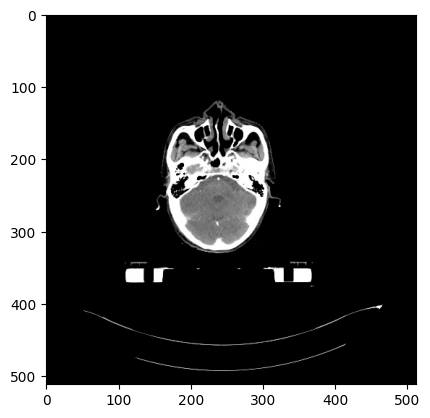

In [24]:
# explanations['answers'][0]
# explanations.keys()
# dict_keys(['img_names', 'locations', 'answers', 'modalities', 'base_types', 'answer_types', 'questions', 'qids', 'content_types', 'triples', 'img_ids', 'q_langs', 'promptified_questions', 'image_paths', 'response_0', 'response_1', 'response_2', 'response_3', 'response_4', 'response_5', 'response_6', 'response_7', 'response_8', 'response_9', 'response_10', 'response_11', 'response_12', 'response_13', 'response_14', 'response_15', 'response_16', 'response_17', 'response_18', 'response_19'])

# print the questions
# print the answers
print(explanations['questions'][0])
print(explanations['answers'][0])

# also show the image
# img.show()
img_path = explanations['image_paths'][0].replace('/mnt/my_ebs_volume/home/ubuntu/Multimodal-Uncertainty-Quantification/dataset/SLAKE/', '/staging/users/tpadhi1/Multimodal-Uncertainty-Quantification/datasets_/')

img = Image.open(img_path)
# img.show()
import matplotlib.pyplot as plt
plt.imshow(img)

In [26]:
img_path = explanations['image_paths'][0].replace('/mnt/my_ebs_volume/home/ubuntu/Multimodal-Uncertainty-Quantification/dataset/SLAKE/', '/staging/users/tpadhi1/Multimodal-Uncertainty-Quantification/datasets_/')

# .replace('dataset', 'datasets_')
# load the above image, and see clip score for all the below responses
img = Image.open(img_path)
# Preprocess the image
image_tensor = preprocess(img).unsqueeze(0).to(device)

# Iterate through responses and compute CLIP scores
responses = []
for key in explanations.keys():
    if key.startswith('response'):
        response_text = explanations[key]['decoded_outputs']
        # response_text = 'the ear color is white'
        print(f"Response: {response_text}\n")

        # Tokenize response text
        text_tensor = tokenizer(response_text, context_length=256).to(device)

        # Compute CLIP similarity scores
        with torch.no_grad():
            image_features, text_features, logit_scale = model(image_tensor, text_tensor)
            similarity_score = (logit_scale * image_features @ text_features.T).squeeze().cpu().numpy()

        print(f"CLIP Score: {similarity_score}\n")

Response: The image is an axial T1-weighted MRI of the abdomen, focusing on the lung and spinal cord.

CLIP Score: 14.274725914001465

Response: The image is an MRI of the abdomen, specifically focusing on the lung and spinal cord. The main organ in the image is the lung, which appears to have a mass.

CLIP Score: 16.59191131591797

Response: The image is a brain MRI, which shows a lesion in the left cerebellar hemisphere. The cerebellum is a region of the brain that plays an important role in motor control, coordination, and balance. A lesion in this area could potentially affect these functions.

CLIP Score: 25.928537368774414

Response: The image is a post-operative MRI of the abdomen, specifically focusing on the Lung and Spinal Cord. The image shows the area after a surgical procedure, and the main organ of interest in this context is the lung.

CLIP Score: 15.36749267578125

Response: The image is a sagittal MRI of the abdomen. A sagittal MRI is a type of magnetic resonance imagi

In [5]:
# if the key starts with 'response' then its a response, and print decoded_outputs
for key in explanations.keys():
    if key.startswith('response'):
        print(explanations[key]['decoded_outputs'])
        print('\n')

The image is an axial T1-weighted MRI of the abdomen, focusing on the lung and spinal cord.


The image is an MRI of the abdomen, specifically focusing on the lung and spinal cord. The main organ in the image is the lung, which appears to have a mass.


The image is a brain MRI, which shows a lesion in the left cerebellar hemisphere. The cerebellum is a region of the brain that plays an important role in motor control, coordination, and balance. A lesion in this area could potentially affect these functions.


The image is a post-operative MRI of the abdomen, specifically focusing on the Lung and Spinal Cord. The image shows the area after a surgical procedure, and the main organ of interest in this context is the lung.


The image is a sagittal MRI of the abdomen. A sagittal MRI is a type of magnetic resonance imaging (MRI) that provides a side view of the body, allowing for visualization of the structures within the abdomen.


The image is a plain computed tomography (CT) scan of the

In [1]:
## ok so biomedclip scores are generated for all the responses, lets see them
path = '/staging/users/tpadhi1/Multimodal-Uncertainty-Quantification/runs_slake/llava_med_slake/grounding/clipscore_0.pkl'

import pickle
with open(path, 'rb') as f:
    data = pickle.load(f)
    

In [6]:
data['response_0'].keys() # biomedclip_score
data['response_0']['biomedclip_score']

35.556427001953125